# Project Report: Global Military Spending, GDP, and Arms Transfer Analysis

## 📊 Project Overview

This project provides a comprehensive analysis of global defense economics by integrating datasets from **SIPRI**, the **World Bank**, and international arms transfer records. The objective is to explore the relationship between economic power (GDP) and military capability, identify patterns in defense spending, and classify high-spending nations using machine learning.

### 🗝️ Key Features
- **Data Integration:** Merging multiple global datasets with automated standardization of country names.
- **Interactive Visuals:** Dynamic charts with sliders and buttons for deep exploration of trends and geographic distributions.
- **Advanced Analytics:** Regression modeling to study GDP-Spending correlation and Interactive Linear Regression to predict spending behavior.
- **Diverse Visualization Gallery:** Including Heatmaps, Choropleth Maps, Treemaps, Pairplots, and Doughnut charts.

### 🛠️ Tech Stack
- **Processing:** `Pandas`, `NumPy`, `Scikit-Learn`
- **Visualization:** `Matplotlib`, `Seaborn`, `Plotly Express`, `Ipywidgets`


In [1]:
# Import the libraries requested for the project.
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.io as pio
import ipywidgets as widgets

# sklearn is used for scaling, regression, and classification.
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

from IPython.display import display

pio.renderers.default = 'notebook_connected'
sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.figsize'] = (14, 7)
pd.set_option('display.max_columns', 120)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

## 1. Data Collection And Dataset Loading

This section loads the SIPRI military spending data, the World Bank GDP dataset, and the arms transfer dataset from the project folder.


In [2]:
# Locate the files. The notebook first looks in the current folder and then in a sibling folder if needed.
base_dir = Path.cwd()
fallback_dir = base_dir.parent / 'Project 1'

def locate_file(filename):
    candidates = [base_dir / filename, fallback_dir / filename]
    for path in candidates:
        if path.exists():
            return path
    raise FileNotFoundError(f'Could not find {filename} in {base_dir} or {fallback_dir}')

sipri_path = locate_file('SIPRI-Milex-data-1949-2024_2.xlsx')
gdp_path = locate_file('WB_WDI_NY_GDP_MKTP_CD_WIDEF.csv')
arms_path = locate_file('import-export-top_1950-2026.csv')

print('SIPRI file:', sipri_path)
print('GDP file:', gdp_path)
print('Arms file:', arms_path)

# Load the raw source files.
sipri_raw = pd.read_excel(sipri_path, sheet_name='Current US$', header=5)
gdp_raw = pd.read_csv(gdp_path)

# The arms transfer file has a long metadata block, then one blank row, then the real header row.
arms_raw = pd.read_csv(arms_path, skiprows=10)

print('\nRaw dataset shapes:')
print('SIPRI:', sipri_raw.shape)
print('GDP:', gdp_raw.shape)
print('Arms:', arms_raw.shape)

SIPRI file: /Users/aryaghosh/Documents/Python with libraries (class)/Project/SIPRI-Milex-data-1949-2024_2.xlsx
GDP file: /Users/aryaghosh/Documents/Python with libraries (class)/Project/WB_WDI_NY_GDP_MKTP_CD_WIDEF.csv
Arms file: /Users/aryaghosh/Documents/Python with libraries (class)/Project/import-export-top_1950-2026.csv

Raw dataset shapes:
SIPRI: (193, 78)
GDP: (262, 106)
Arms: (140, 166)


## 2. Data Cleaning And Data Preparation

The next cells clean each source, reshape wide tables into long format, standardize country names, and merge the datasets for analysis.


In [3]:
# -----------------------------
# 1. Clean SIPRI military spending data
# -----------------------------

# Rename the first column to Country and drop unnamed helper columns.
sipri = sipri_raw.copy()
sipri = sipri.rename(columns={sipri.columns[0]: 'Country'})
sipri = sipri.loc[:, ~sipri.columns.astype(str).str.contains('^Unnamed')]

# Replace non-numeric placeholders used by SIPRI.
sipri = sipri.replace({'...': np.nan, 'xxx': np.nan, '. .': np.nan})

# Identify all year columns automatically.
sipri_year_cols = [col for col in sipri.columns if str(col).isdigit()]
sipri[sipri_year_cols] = sipri[sipri_year_cols].apply(pd.to_numeric, errors='coerce')

# Remove unnecessary rows such as region headings by keeping only rows that contain at least one numeric year value.
sipri = sipri[sipri[sipri_year_cols].notna().any(axis=1)].copy()
sipri = sipri[['Country'] + sipri_year_cols].copy()
sipri['Country'] = sipri['Country'].astype(str).str.strip()

# Convert from wide format to long format using melt.
sipri_long = sipri.melt(
    id_vars='Country',
    value_vars=sipri_year_cols,
    var_name='Year',
    value_name='Military_Spending'
)

sipri_long['Year'] = sipri_long['Year'].astype(int)
sipri_long = sipri_long.dropna(subset=['Military_Spending']).reset_index(drop=True)

display(sipri_long.head())
print('SIPRI long shape:', sipri_long.shape)

,Country,Year,Military_Spending
0,Costa Rica,1949,0.00
1,Mexico,1949,34.80
2,United States of America,1949,"14,088.16"
3,Argentina,1949,0.00
4,Peru,1949,23.90


SIPRI long shape: (8846, 3)


In [4]:
# -----------------------------
# 2. Clean GDP data
# -----------------------------

# The GDP file contains many metadata columns before the yearly columns.
# Keep only the country label plus the year columns and then melt it to long format.
gdp = gdp_raw.copy()
gdp_year_cols = [col for col in gdp.columns if str(col).isdigit()]
gdp = gdp[['REF_AREA_LABEL'] + gdp_year_cols].rename(columns={'REF_AREA_LABEL': 'Country'})

gdp_long = gdp.melt(
    id_vars='Country',
    value_vars=gdp_year_cols,
    var_name='Year',
    value_name='GDP'
)

gdp_long['Country'] = gdp_long['Country'].astype(str).str.strip()
gdp_long['Year'] = gdp_long['Year'].astype(int)
gdp_long['GDP'] = pd.to_numeric(gdp_long['GDP'], errors='coerce')
gdp_long = gdp_long.dropna(subset=['GDP']).reset_index(drop=True)

display(gdp_long.head())
print('GDP long shape:', gdp_long.shape)

,Country,Year,GDP
0,Syrian Arab Republic,1960,"857,704,413.41"
1,Low & middle income,1960,"266,021,244,949.63"
2,Morocco,1960,"2,037,154,741.93"
3,Botswana,1960,"30,411,413.66"
4,Middle income,1960,"254,380,808,746.11"


GDP long shape: (14561, 3)


In [5]:
# -----------------------------
# 3. Clean arms transfer data
# -----------------------------

# Remove fully empty columns, then keep the supplier country, yearly values, and the total period value.
arms = arms_raw.copy().dropna(axis=1, how='all')
arms = arms.rename(columns={'Supplier': 'Country', '1950-2026': 'Value'})
arms['Country'] = arms['Country'].astype(str).str.strip()

arms_year_cols = [col for col in arms.columns if str(col).isdigit()]
arms = arms[['Country'] + arms_year_cols + ['Value']].copy()

# Convert all transfer values to numeric.
for col in arms_year_cols + ['Value']:
    arms[col] = pd.to_numeric(arms[col], errors='coerce')

# Keep the compact Country / Value summary table requested in the instructions.
arms_summary = arms[['Country', 'Value']].dropna(subset=['Country']).reset_index(drop=True)

# Also create a long-form yearly table so it can be merged on Country and Year.
arms_long = arms.melt(
    id_vars='Country',
    value_vars=arms_year_cols,
    var_name='Year',
    value_name='Arms_Transfer_Value'
)

arms_long['Year'] = arms_long['Year'].astype(int)
arms_long = arms_long.dropna(subset=['Arms_Transfer_Value']).reset_index(drop=True)

display(arms_summary.head())
display(arms_long.head())
print('Arms summary shape:', arms_summary.shape)
print('Arms long shape:', arms_long.shape)

,Country,Value
0,United States,767217
1,Soviet Union,454224
2,Russia,161494
3,United Kingdom,146592
4,France,144131


,Country,Year,Arms_Transfer_Value
0,United States,1950,"1,447.00"
1,Soviet Union,1950,"4,071.00"
2,United Kingdom,1950,"2,194.00"
3,France,1950,14.00
4,Italy,1950,119.00


Arms summary shape: (140, 2)
Arms long shape: (2913, 3)


In [6]:
# -----------------------------
# 4. Standardize country names and merge datasets
# -----------------------------

# Country names differ across sources, so this mapping improves merge coverage.
country_map = {
    'United States of America': 'United States',
    'Russian Federation': 'Russia',
    'Syrian Arab Republic': 'Syria',
    'Iran, Islamic Rep.': 'Iran',
    'Egypt, Arab Rep.': 'Egypt',
    'Yemen, Rep.': 'Yemen',
    'Korea, Rep.': 'South Korea',
    "Korea, Dem. People's Rep.": 'North Korea',
    'Viet Nam': 'Vietnam',
    'Slovak Republic': 'Slovakia',
    'Czechia': 'Czech Republic',
    'Brunei Darussalam': 'Brunei',
    'Kyrgyz Republic': 'Kyrgyzstan',
    'Lao PDR': 'Laos',
    'Turkiye': 'Turkey',
    'Türkiye': 'Turkey',
    'Venezuela, RB': 'Venezuela',
    'Bahamas, The': 'Bahamas',
    'Gambia, The': 'Gambia',
    'Congo, Dem. Rep.': 'Democratic Republic of the Congo',
    'Congo, Rep.': 'Republic of the Congo',
    'Hong Kong SAR, China': 'Hong Kong',
    'Macao SAR, China': 'Macao',
    'West Bank and Gaza': 'Palestine',
    'Micronesia, Fed. Sts.': 'Micronesia',
    'St. Kitts and Nevis': 'Saint Kitts and Nevis',
    'St. Lucia': 'Saint Lucia',
    'St. Vincent and the Grenadines': 'Saint Vincent and the Grenadines',
    'Cape Verde': 'Cabo Verde',
    "Cote d'Ivoire": 'Cote dIvoire',
    'Korea, South': 'South Korea',
    'Korea, North': 'North Korea',
    'Congo, DR': 'Democratic Republic of the Congo',
    'Congo, Republic': 'Republic of the Congo',
    'Timor Leste': 'Timor-Leste'
}

def standardize_country(name):
    if pd.isna(name):
        return name
    name = str(name).strip()
    return country_map.get(name, name)

for df in [sipri_long, gdp_long, arms_summary, arms_long]:
    df['Country'] = df['Country'].apply(standardize_country)

# Merge the long-form datasets on Country and Year.
merged = sipri_long.merge(gdp_long, on=['Country', 'Year'], how='left')
merged = merged.merge(arms_long, on=['Country', 'Year'], how='left')

# Create a few analytical helper columns for later charts.
merged['Military_Spending_USD'] = merged['Military_Spending'] * 1_000_000
merged['Military_Burden_pct_GDP'] = (merged['Military_Spending_USD'] / merged['GDP']) * 100
merged['Arms_Dependency_Ratio'] = merged['Arms_Transfer_Value'] / merged['Military_Spending']

# Scale military spending to a 0-1 range for marker sizing in interactive visuals.
merged['Spending_Scaled'] = np.nan
non_null_spending = merged[['Military_Spending']].dropna()
if not non_null_spending.empty:
    scaler = MinMaxScaler()
    merged.loc[non_null_spending.index, 'Spending_Scaled'] = scaler.fit_transform(non_null_spending)

merge_summary = pd.DataFrame({
    'Metric': [
        'Rows in merged table',
        'Unique countries in SIPRI',
        'Unique countries in GDP',
        'Unique countries in arms',
        'GDP coverage in merged table',
        'Arms coverage in merged table'
    ],
    'Value': [
        len(merged),
        sipri_long['Country'].nunique(),
        gdp_long['Country'].nunique(),
        arms_long['Country'].nunique(),
        merged['GDP'].notna().mean(),
        merged['Arms_Transfer_Value'].notna().mean()
    ]
})

display(merge_summary)
display(merged.head())

,Metric,Value
0,Rows in merged table,"8,846.00"
1,Unique countries in SIPRI,174.00
2,Unique countries in GDP,262.00
3,Unique countries in arms,140.00
4,GDP coverage in merged table,0.90
5,Arms coverage in merged table,0.27


,Country,Year,Military_Spending,GDP,Arms_Transfer_Value,Military_Spending_USD,Military_Burden_pct_GDP,Arms_Dependency_Ratio,Spending_Scaled
0,Costa Rica,1949,0.00,NaN,NaN,0.00,NaN,NaN,0.00
1,Mexico,1949,34.80,NaN,NaN,"34,797,687.86",NaN,NaN,0.00
2,United States,1949,"14,088.16",NaN,NaN,"14,088,155,590.70",NaN,NaN,0.01
3,Argentina,1949,0.00,NaN,NaN,0.00,NaN,NaN,0.00
4,Peru,1949,23.90,NaN,NaN,"23,902,768.40",NaN,NaN,0.00


## 3. Exploratory Data Analysis And Regression Modeling

This section builds a latest-year analytical view of the data and uses regression to study the relationship between GDP and military spending.


In [7]:
# -----------------------------
# 5. Build a latest-year analysis view
# -----------------------------

latest_year = int(merged['Year'].max())
latest_df = merged[merged['Year'] == latest_year].copy()

# Show the top countries in the latest available year.
latest_top = latest_df.nlargest(15, 'Military_Spending')[
    ['Country', 'Military_Spending', 'GDP', 'Arms_Transfer_Value', 'Military_Burden_pct_GDP']
].reset_index(drop=True)
display(latest_top)

# Fit a simple linear regression between log GDP and log military spending.
# This gives the scatter plot a stronger analytical angle while using sklearn meaningfully.
regression_df = latest_df.dropna(subset=['GDP', 'Military_Spending']).copy()
regression_df = regression_df[(regression_df['GDP'] > 0) & (regression_df['Military_Spending'] > 0)].copy()

regression_df['log_GDP'] = np.log10(regression_df['GDP'])
regression_df['log_Military_Spending'] = np.log10(regression_df['Military_Spending'])

regression_model = LinearRegression()
regression_model.fit(regression_df[['log_GDP']], regression_df['log_Military_Spending'])
regression_df['Predicted_log_Spending'] = regression_model.predict(regression_df[['log_GDP']])
regression_df['Residual'] = regression_df['log_Military_Spending'] - regression_df['Predicted_log_Spending']

print(f'Latest year available: {latest_year}')
print(f'Regression R^2: {regression_model.score(regression_df[["log_GDP"]], regression_df["log_Military_Spending"]):.3f}')
print(f'Slope: {regression_model.coef_[0]:.3f}')

display(regression_df.nlargest(10, 'Residual')[['Country', 'GDP', 'Military_Spending', 'Residual']])

,Country,Military_Spending,GDP,Arms_Transfer_Value,Military_Burden_pct_GDP
0,United States,"997,309.00","28,750,956,130,731.20","13,651.00",3.47
1,China,"313,658.33","18,743,803,170,827.16","1,294.00",1.67
2,Russia,"148,967.28","2,173,835,806,671.66","1,994.00",6.85
3,Germany,"88,458.48","4,685,592,577,804.69","2,108.00",1.89
4,India,"86,125.98","3,909,891,533,858.08",94.00,2.20
5,United Kingdom,"81,763.17","3,686,033,044,482.13",884.00,2.22
6,Saudi Arabia,"80,330.67","1,239,804,533,333.33",NaN,6.48
7,Ukraine,"64,704.99","190,741,262,414.70",29.00,33.92
8,France,"64,675.02","3,160,442,622,465.08","2,472.00",2.05
9,Japan,"55,273.90","4,027,597,523,550.58",21.00,1.37


Latest year available: 2024
Regression R^2: 0.824
Slope: 1.004


,Country,GDP,Military_Spending,Residual
8813,Ukraine,"190,741,262,414.70","64,704.99",1.36
8839,Israel,"540,379,921,261.68","46,505.30",0.76
8693,Algeria,"269,322,281,664.77","21,811.24",0.74
8782,Myanmar,"74,068,349,523.81","5,011.27",0.66
8812,Russia,"2,173,835,806,671.66","148,967.28",0.66
8844,Saudi Arabia,"1,239,804,533,333.33","80,330.67",0.64
8700,Burundi,"3,082,433,067.33",171.83,0.58
8843,Oman,"107,137,198,769.39","5,988.30",0.58
8807,Armenia,"25,955,275,380.03","1,418.01",0.57
8808,Azerbaijan,"74,315,882,352.94","3,777.09",0.54


## 4. Data Visualization And Comparative Analysis

These charts compare military spending, GDP, military burden, and arms transfer patterns across countries and over time.


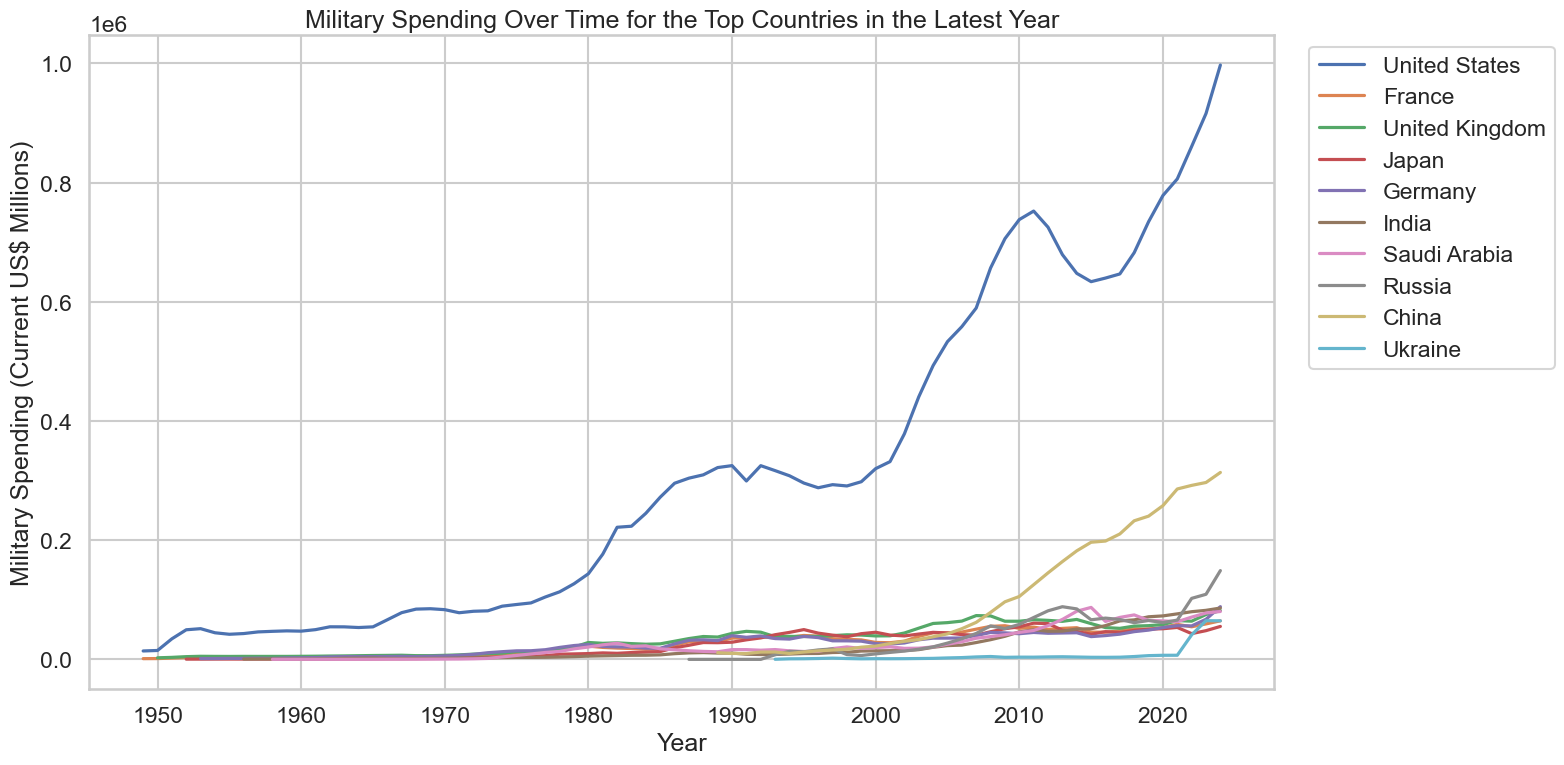

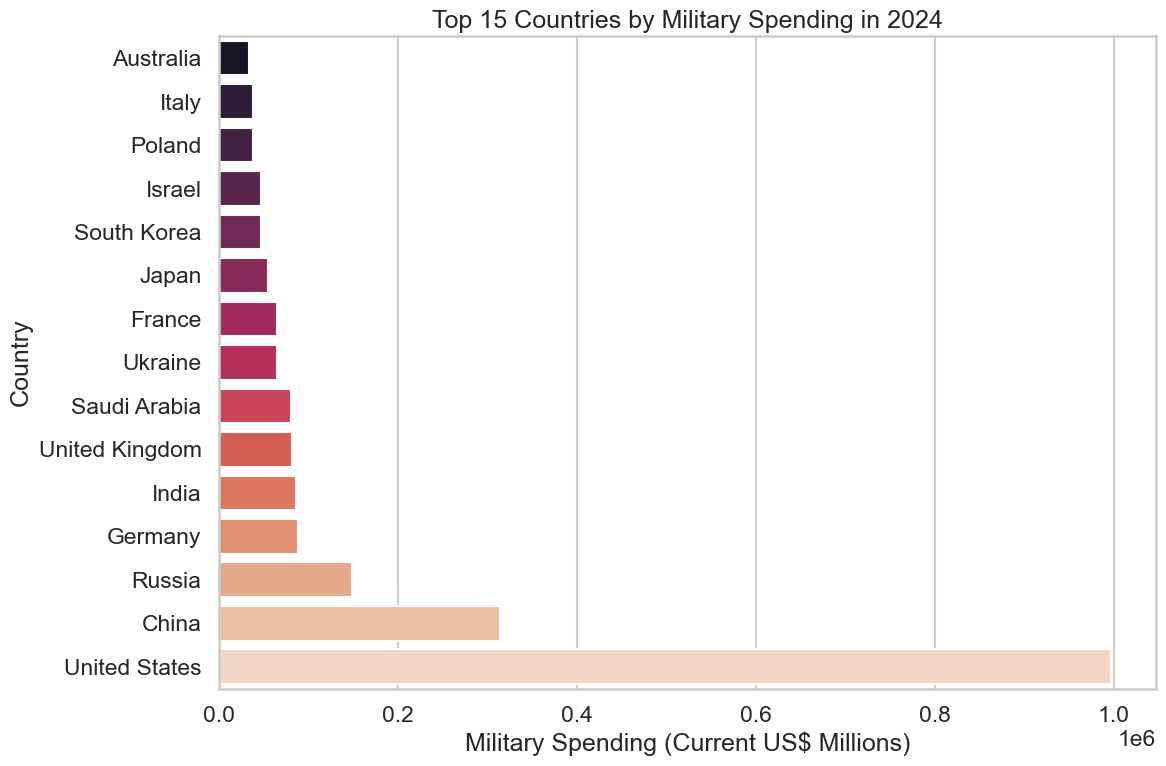

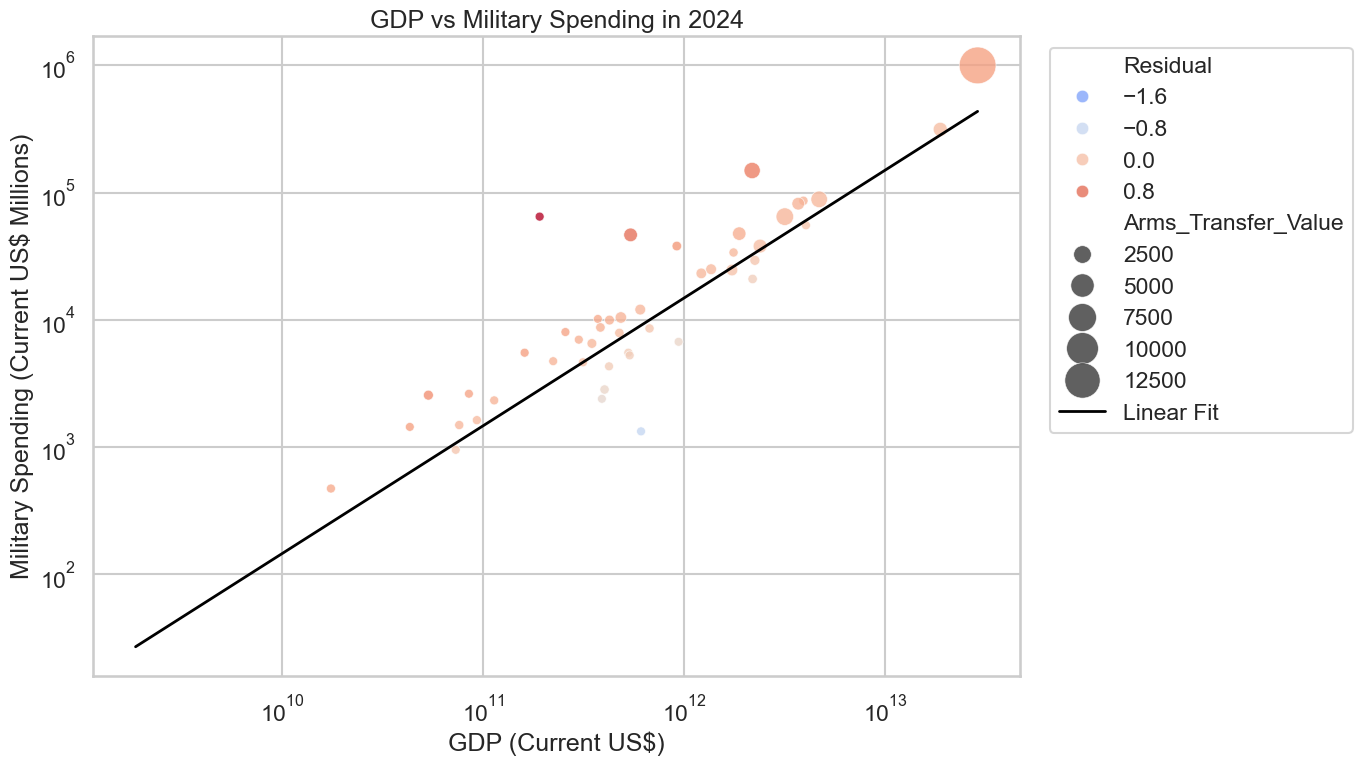

In [8]:
# -----------------------------
# 6. Visualizations: line plot, bar chart, scatter plot
# -----------------------------

trend_metric_options = {
    'Military Spending': {
        'column': 'Military_Spending',
        'label': 'Military Spending (Current US$ Millions)',
        'palette': 'rocket'
    },
    'Military Burden % GDP': {
        'column': 'Military_Burden_pct_GDP',
        'label': 'Military Spending as % of GDP',
        'palette': 'viridis'
    }
}

line_metric_buttons = widgets.ToggleButtons(
    options=['Military Spending', 'Military Burden % GDP'],
    description='Metric:',
    button_style='info'
)

line_top_slider = widgets.IntSlider(
    value=10,
    min=5,
    max=15,
    step=1,
    description='Top N:',
    continuous_update=False
)

def draw_interactive_line(metric_label, top_n):
    metric_config = trend_metric_options[metric_label]
    selected_countries = latest_df.nlargest(top_n, 'Military_Spending')['Country'].tolist()
    trend_df = merged[merged['Country'].isin(selected_countries)].dropna(
        subset=[metric_config['column']]
    ).copy()

    plt.figure(figsize=(16, 8))
    sns.lineplot(
        data=trend_df,
        x='Year',
        y=metric_config['column'],
        hue='Country',
        linewidth=2.3
    )
    plt.title(f'{metric_label} Over Time for the Top {top_n} Countries')
    plt.xlabel('Year')
    plt.ylabel(metric_config['label'])
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

display(
    widgets.VBox(
        [
            widgets.HTML('<h4>Interactive Trend Line</h4><p>Slider changes how many countries are shown, and the buttons switch the metric.</p>'),
            widgets.HBox([line_metric_buttons, line_top_slider]),
            widgets.interactive_output(
                draw_interactive_line,
                {'metric_label': line_metric_buttons, 'top_n': line_top_slider}
            )
        ]
    )
)

# Static line plot for military spending over time.
top_countries = latest_df.nlargest(10, 'Military_Spending')['Country'].tolist()
line_df = merged[merged['Country'].isin(top_countries)].copy()

plt.figure(figsize=(16, 8))
sns.lineplot(data=line_df, x='Year', y='Military_Spending', hue='Country', linewidth=2.3)
plt.title('Military Spending Over Time for the Top Countries in the Latest Year')
plt.xlabel('Year')
plt.ylabel('Military Spending (Current US$ Millions)')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Static bar chart for the top countries in the latest year.
bar_df = latest_df.nlargest(15, 'Military_Spending').sort_values('Military_Spending', ascending=True)

plt.figure(figsize=(12, 8))
sns.barplot(data=bar_df, x='Military_Spending', y='Country', hue='Country', palette='rocket', legend=False)
plt.title(f'Top 15 Countries by Military Spending in {latest_year}')
plt.xlabel('Military Spending (Current US$ Millions)')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

# Scatter plot: GDP vs Military Spending with a fitted regression line in log space.
plt.figure(figsize=(14, 8))
sns.scatterplot(
    data=regression_df,
    x='GDP',
    y='Military_Spending',
    size='Arms_Transfer_Value',
    hue='Residual',
    palette='coolwarm',
    sizes=(40, 700),
    alpha=0.78
)

fit_df = regression_df.sort_values('GDP').copy()
fit_df['Predicted_Military_Spending'] = 10 ** fit_df['Predicted_log_Spending']
plt.plot(fit_df['GDP'], fit_df['Predicted_Military_Spending'], color='black', linewidth=2, label='Linear Fit')

plt.xscale('log')
plt.yscale('log')
plt.title(f'GDP vs Military Spending in {latest_year}')
plt.xlabel('GDP (Current US$)')
plt.ylabel('Military Spending (Current US$ Millions)')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

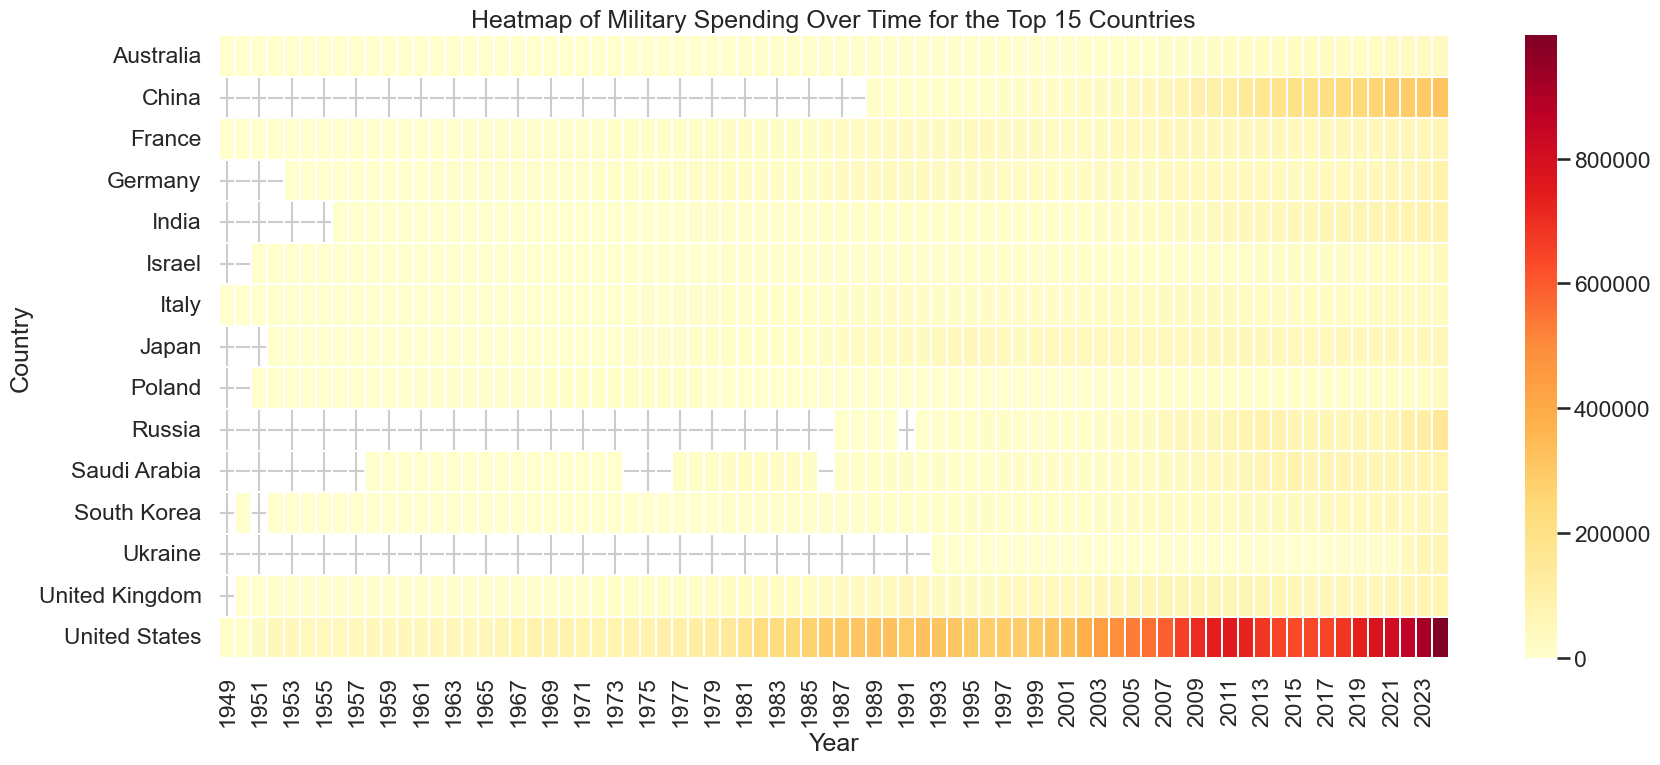

In [9]:
# -----------------------------
# 7. Visualizations: heatmap, interactive comparison, and world map
# -----------------------------

available_years = sorted(merged['Year'].dropna().astype(int).unique().tolist())

# Static heatmap for military spending over time.
heatmap_countries = latest_df.nlargest(15, 'Military_Spending')['Country'].tolist()
heatmap_df = merged[merged['Country'].isin(heatmap_countries)].copy()
heatmap_pivot = heatmap_df.pivot_table(index='Country', columns='Year', values='Military_Spending', aggfunc='mean')

plt.figure(figsize=(18, 8))
sns.heatmap(heatmap_pivot, cmap='YlOrRd', linewidths=0.15)
plt.title('Heatmap of Military Spending Over Time for the Top 15 Countries')
plt.xlabel('Year')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

comparison_metric_options = {
    'Military Spending': {
        'column': 'Military_Spending',
        'label': 'Military Spending (Current US$ Millions)',
        'palette': 'crest'
    },
    'Military Burden % GDP': {
        'column': 'Military_Burden_pct_GDP',
        'label': 'Military Spending as % of GDP',
        'palette': 'viridis'
    }
}

comparison_year_slider = widgets.SelectionSlider(
    options=available_years,
    value=latest_year,
    description='Year:',
    continuous_update=False
)

comparison_view_buttons = widgets.ToggleButtons(
    options=['Bar Chart', 'Heatmap'],
    description='View:',
    button_style='success'
)

comparison_metric_buttons = widgets.ToggleButtons(
    options=['Military Spending', 'Military Burden % GDP'],
    description='Metric:',
    button_style='warning'
)

def draw_comparison_view(year, view_name, metric_label):
    metric_config = comparison_metric_options[metric_label]

    if view_name == 'Bar Chart':
        year_df = merged[merged['Year'] == year].dropna(subset=[metric_config['column']]).copy()
        year_df = year_df.nlargest(12, metric_config['column']).sort_values(metric_config['column'], ascending=True)

        plt.figure(figsize=(13, 8))
        sns.barplot(
            data=year_df,
            x=metric_config['column'],
            y='Country',
            hue='Country',
            palette=metric_config['palette'],
            legend=False
        )
        plt.title(f'Top 12 Countries by {metric_label} in {year}')
        plt.xlabel(metric_config['label'])
        plt.ylabel('Country')
        plt.tight_layout()
        plt.show()
    else:
        history_df = merged[
            (merged['Country'].isin(heatmap_countries)) & (merged['Year'] <= year)
        ].dropna(subset=[metric_config['column']]).copy()
        history_pivot = history_df.pivot_table(
            index='Country',
            columns='Year',
            values=metric_config['column'],
            aggfunc='mean'
        )

        plt.figure(figsize=(18, 8))
        sns.heatmap(history_pivot, cmap='YlGnBu', linewidths=0.15)
        plt.title(f'{metric_label} Heatmap Up To {year}')
        plt.xlabel('Year')
        plt.ylabel('Country')
        plt.tight_layout()
        plt.show()

display(
    widgets.VBox(
        [
            widgets.HTML('<h4>Interactive Comparison View</h4><p>Slider changes the year. Buttons switch between bar chart and heatmap, and also change the metric.</p>'),
            widgets.HBox([comparison_year_slider]),
            widgets.HBox([comparison_view_buttons, comparison_metric_buttons]),
            widgets.interactive_output(
                draw_comparison_view,
                {
                    'year': comparison_year_slider,
                    'view_name': comparison_view_buttons,
                    'metric_label': comparison_metric_buttons
                }
            )
        ]
    )
)

map_metric_buttons = widgets.ToggleButtons(
    options=['Military Spending', 'Arms Transfers'],
    description='Map metric:',
    button_style='primary'
)

map_year_slider = widgets.SelectionSlider(
    options=available_years,
    value=latest_year,
    description='Map year:',
    continuous_update=False
)

def draw_world_map(year, metric_label):
    metric_column = 'Military_Spending' if metric_label == 'Military Spending' else 'Arms_Transfer_Value'
    color_scale = 'Reds' if metric_label == 'Military Spending' else 'Blues'
    map_df = merged[merged['Year'] == year].dropna(subset=[metric_column]).copy()

    fig = px.choropleth(
        map_df,
        locations='Country',
        locationmode='country names',
        color=metric_column,
        hover_name='Country',
        hover_data={
            'Year': True,
            'GDP': ':.2f',
            'Arms_Transfer_Value': ':.2f',
            'Military_Burden_pct_GDP': ':.2f',
            'Military_Spending': ':.2f'
        },
        color_continuous_scale=color_scale,
        title=f'{metric_label} World Map ({year})'
    )
    fig.update_layout(geo=dict(showframe=False, showcoastlines=True))
    fig.show()

display(
    widgets.VBox(
        [
            widgets.HTML('<h4>Interactive World Map</h4><p>Use the slider to move across years, and the buttons to switch the map between spending and arms transfers.</p>'),
            widgets.HBox([map_year_slider, map_metric_buttons]),
            widgets.interactive_output(
                draw_world_map,
                {'year': map_year_slider, 'metric_label': map_metric_buttons}
            )
        ]
    )
)

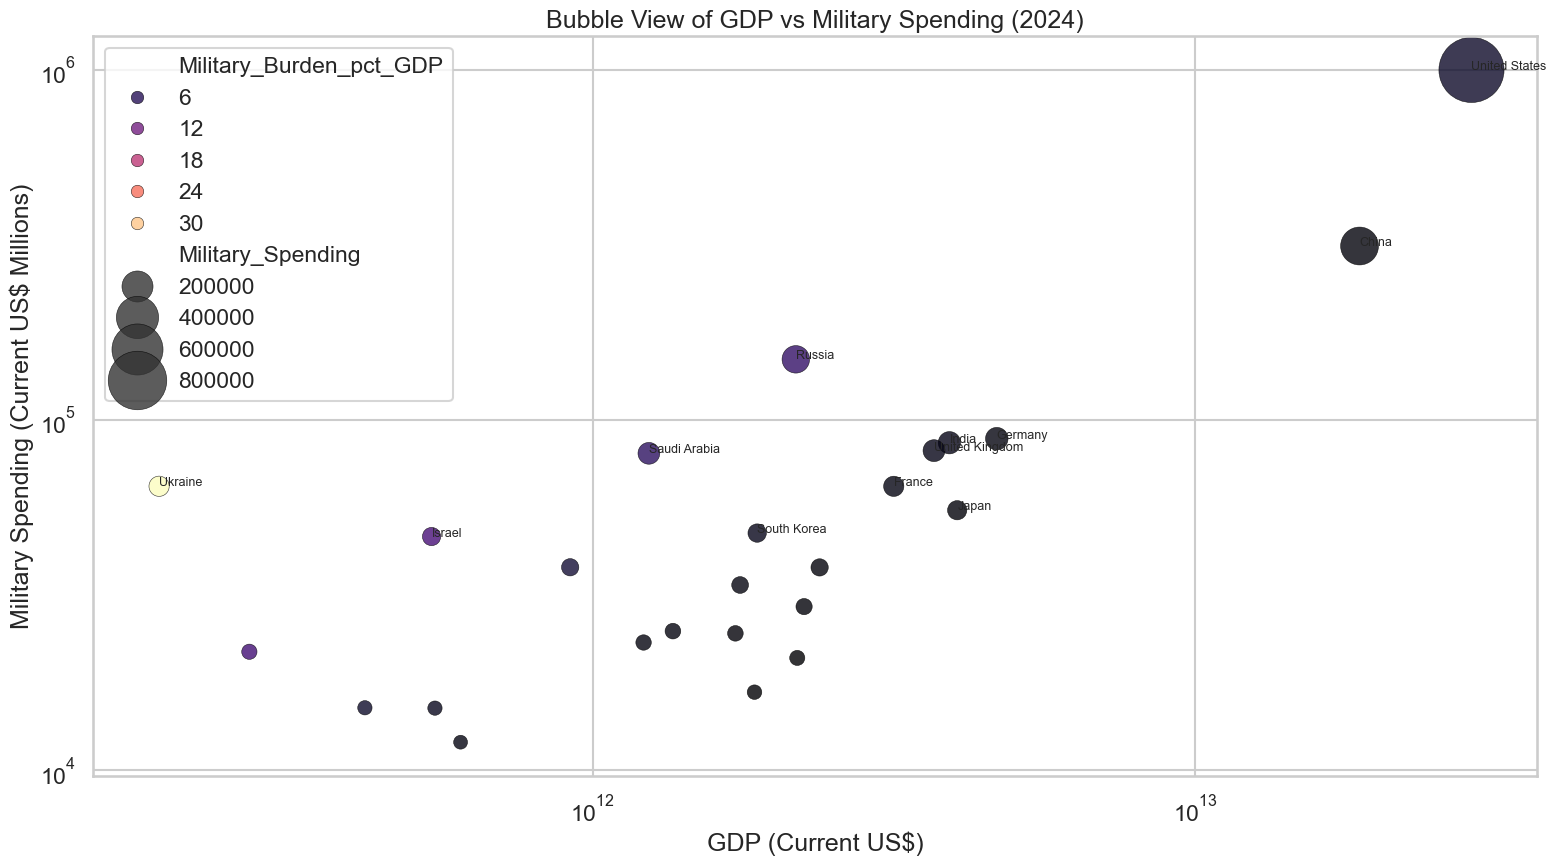

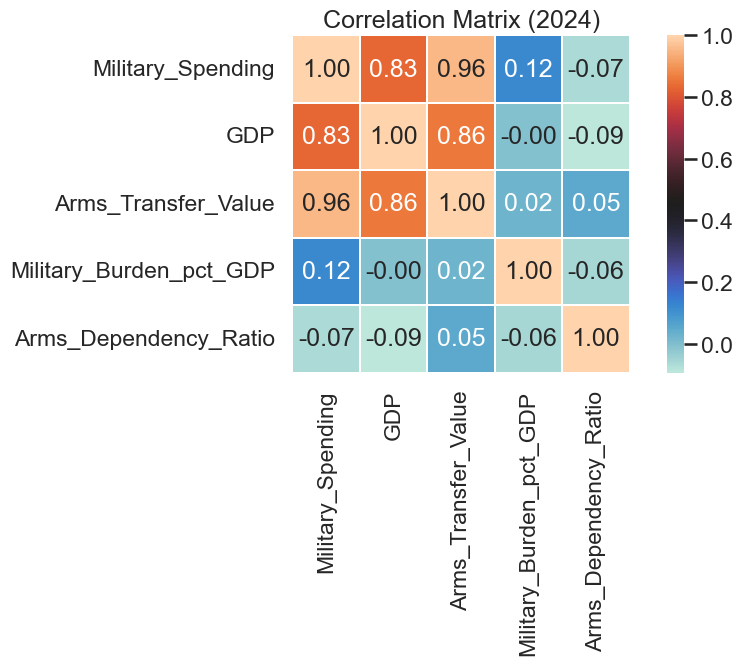

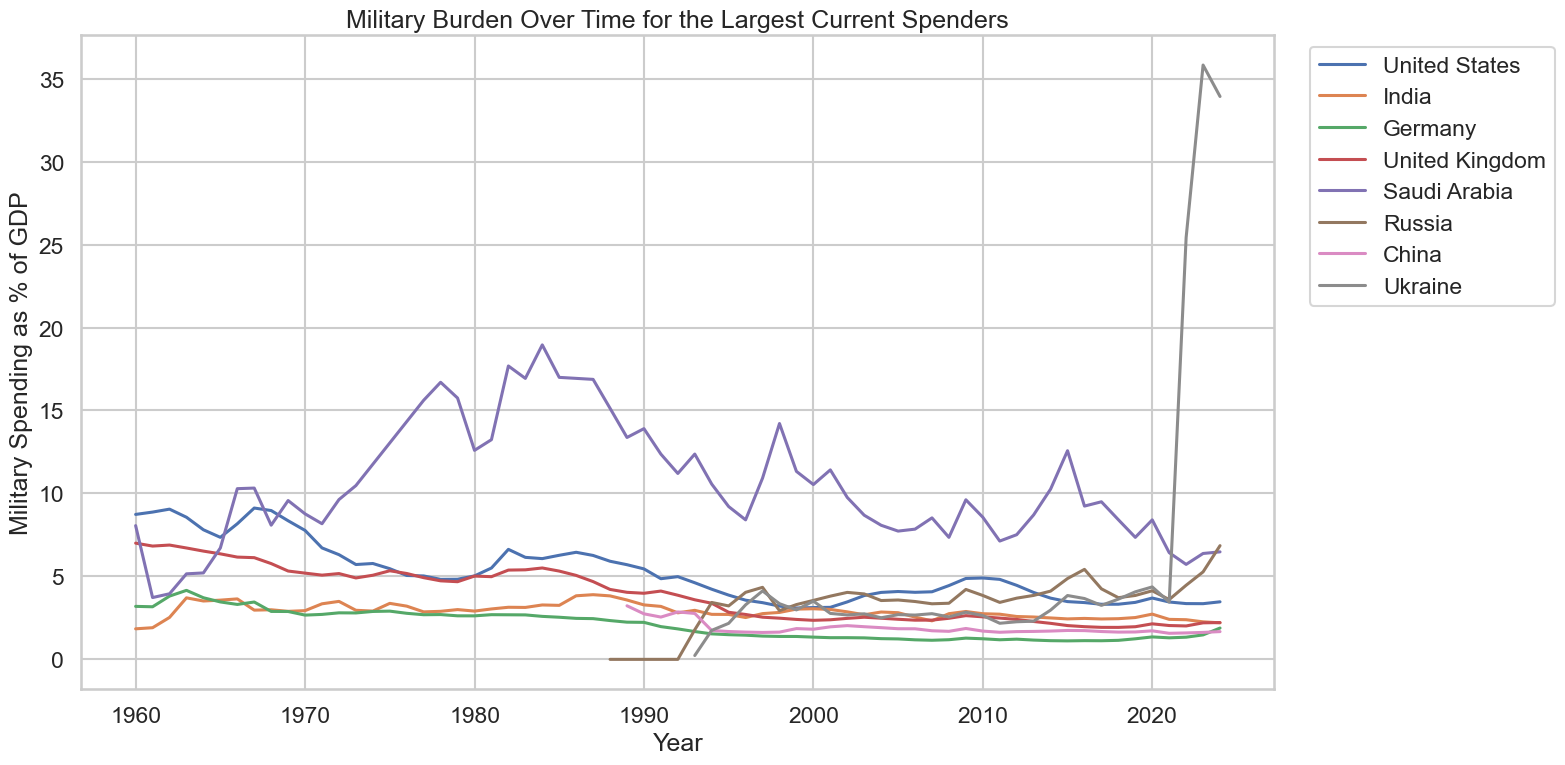

In [10]:
# -----------------------------
# 8. Additional visualizations
# -----------------------------

# Bubble chart combining GDP, military spending, and military burden.
bubble_df = latest_df.dropna(subset=['GDP', 'Military_Spending']).copy()
bubble_df = bubble_df.nlargest(25, 'Military_Spending').sort_values('Military_Spending', ascending=False)

plt.figure(figsize=(16, 9))
sns.scatterplot(
    data=bubble_df,
    x='GDP',
    y='Military_Spending',
    size='Military_Spending',
    hue='Military_Burden_pct_GDP',
    palette='magma',
    sizes=(100, 2200),
    alpha=0.8,
    edgecolor='black',
    linewidth=0.4
)
for row in bubble_df.head(12).itertuples():
    plt.text(row.GDP, row.Military_Spending, row.Country, fontsize=9)
plt.xscale('log')
plt.yscale('log')
plt.title(f'Bubble View of GDP vs Military Spending ({latest_year})')
plt.xlabel('GDP (Current US$)')
plt.ylabel('Military Spending (Current US$ Millions)')
plt.tight_layout()
plt.show()

# Treemap of the top military spenders.
treemap_df = latest_df.nlargest(20, 'Military_Spending').copy()
fig = px.treemap(
    treemap_df,
    path=[px.Constant(f'Top Military Spenders {latest_year}'), 'Country'],
    values='Military_Spending',
    color='Military_Burden_pct_GDP',
    color_continuous_scale='Sunsetdark',
    hover_data={'GDP': ':.2f', 'Arms_Transfer_Value': ':.2f', 'Military_Burden_pct_GDP': ':.2f'}
)
fig.update_layout(margin=dict(t=50, l=20, r=20, b=20))
fig.show()

# Correlation heatmap of key indicators.
corr_df = latest_df[['Military_Spending', 'GDP', 'Arms_Transfer_Value', 'Military_Burden_pct_GDP', 'Arms_Dependency_Ratio']].copy()
corr_matrix = corr_df.corr(numeric_only=True)

plt.figure(figsize=(10, 7))
sns.heatmap(corr_matrix, annot=True, cmap='icefire', fmt='.2f', linewidths=0.3, square=True)
plt.title(f'Correlation Matrix ({latest_year})')
plt.tight_layout()
plt.show()

# Military burden trend for the biggest current spenders.
burden_countries = latest_df.nlargest(8, 'Military_Spending')['Country'].tolist()
burden_df = merged[merged['Country'].isin(burden_countries)].dropna(subset=['Military_Burden_pct_GDP']).copy()

plt.figure(figsize=(16, 8))
sns.lineplot(data=burden_df, x='Year', y='Military_Burden_pct_GDP', hue='Country', linewidth=2.2)
plt.title('Military Burden Over Time for the Largest Current Spenders')
plt.xlabel('Year')
plt.ylabel('Military Spending as % of GDP')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

summary_view_buttons = widgets.ToggleButtons(
    options=['Boxplot', 'Area Chart'],
    description='Summary view:',
    button_style='info'
)

def draw_summary_view(view_name):
    if view_name == 'Boxplot':
        box_df = merged[merged['Country'].isin(top_countries)].dropna(subset=['Military_Burden_pct_GDP']).copy()

        plt.figure(figsize=(15, 8))
        sns.boxplot(data=box_df, x='Country', y='Military_Burden_pct_GDP', hue='Country', palette='viridis', legend=False)
        plt.title('Distribution of Military Burden for the Top Spenders')
        plt.xlabel('Country')
        plt.ylabel('Military Spending as % of GDP')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()
    else:
        stack_df = line_df.pivot_table(index='Year', columns='Country', values='Military_Spending', aggfunc='sum').fillna(0)
        stack_df.plot(kind='area', stacked=True, figsize=(16, 8), colormap='tab20')
        plt.title('Stacked Area Chart of Military Spending Over Time')
        plt.xlabel('Year')
        plt.ylabel('Military Spending (Current US$ Millions)')
        plt.tight_layout()
        plt.show()

display(
    widgets.VBox(
        [
            widgets.HTML('<h4>Interactive Summary View</h4><p>These buttons switch between two additional summary visuals.</p>'),
            summary_view_buttons,
            widgets.interactive_output(draw_summary_view, {'view_name': summary_view_buttons})
        ]
    )
)

## 5. Advanced Visual Gallery: Distribution, Relationships, and Shares

This section adds high-impact visuals including distributions, multi-variable relationships, and market share breakdowns to provide a deeper understanding of the defense landscape.


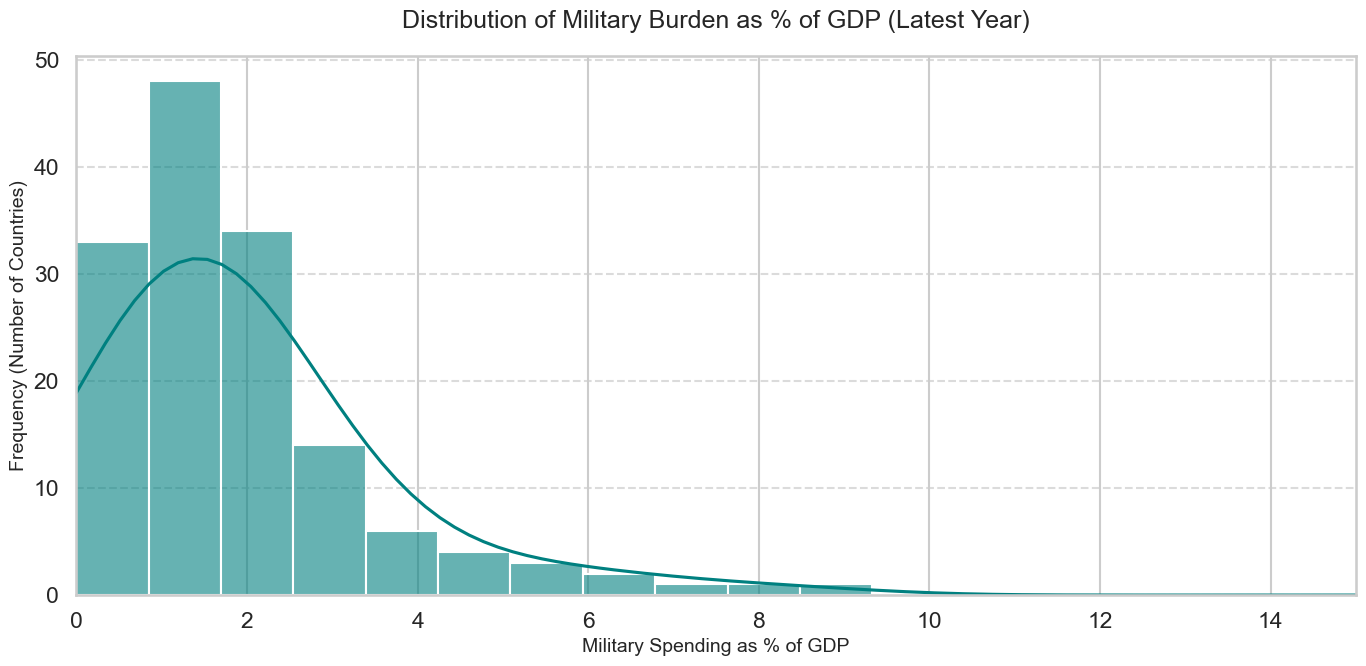

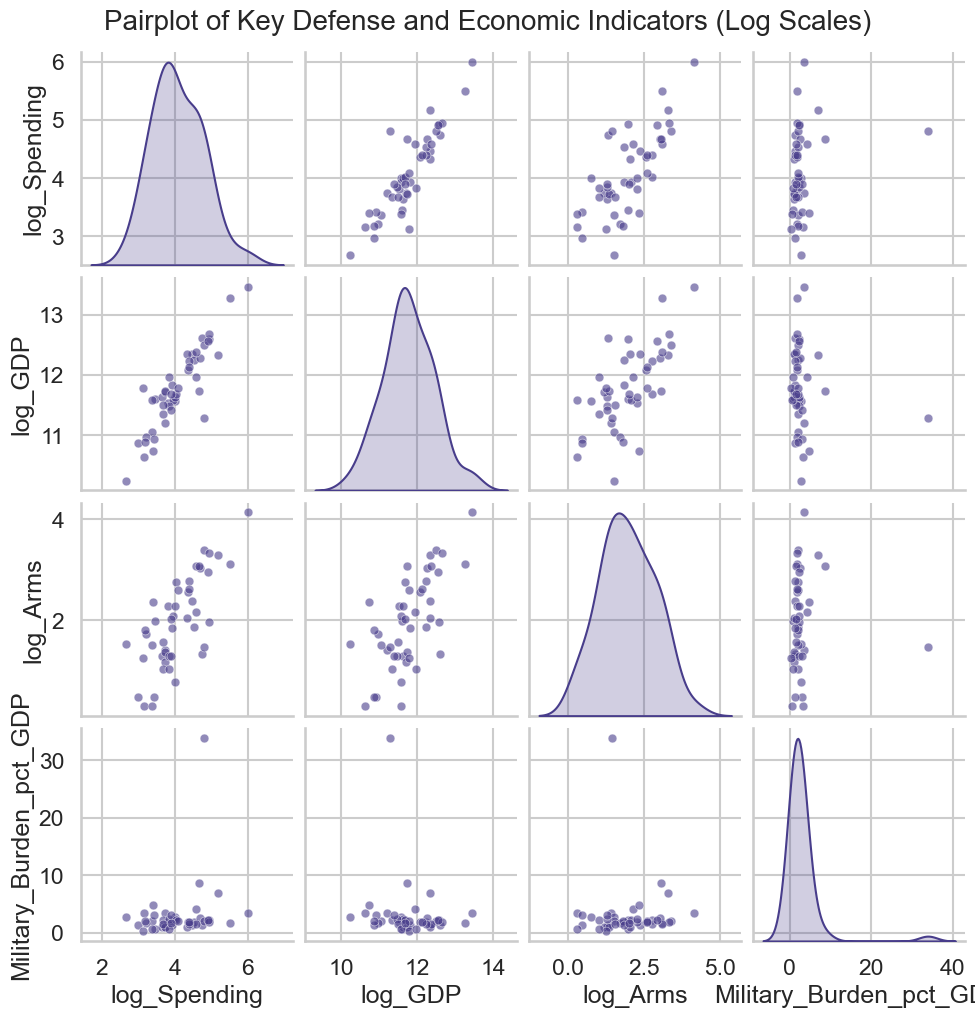

In [11]:
# -----------------------------
# 9. Advanced Visual Gallery: Histogram, Pairplot, and Doughnut Chart
# -----------------------------

# A. Histogram: Distribution of Military Burden % GDP
plt.figure(figsize=(14, 7))
sns.histplot(data=latest_df, x='Military_Burden_pct_GDP', bins=40, kde=True, color='teal', alpha=0.6)
plt.title('Distribution of Military Burden as % of GDP (Latest Year)', fontsize=18, pad=20)
plt.xlabel('Military Spending as % of GDP', fontsize=14)
plt.ylabel('Frequency (Number of Countries)', fontsize=14)
plt.xlim(0, 15) # Focused on the main distribution; outliers like Ukraine are much higher.
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# B. Pairplot: Relationships between key numeric variables
# Using a subset of variables and log scales for better visualization of skewed data.
pairplot_df = latest_df[['Military_Spending', 'GDP', 'Arms_Transfer_Value', 'Military_Burden_pct_GDP']].copy()
pairplot_df = pairplot_df[pairplot_df > 0].dropna()

# Log transformation for variables with extreme ranges (Spending, GDP, Arms)
pairplot_df['log_Spending'] = np.log10(pairplot_df['Military_Spending'])
pairplot_df['log_GDP'] = np.log10(pairplot_df['GDP'])
pairplot_df['log_Arms'] = np.log10(pairplot_df['Arms_Transfer_Value'])

g = sns.pairplot(
    pairplot_df[['log_Spending', 'log_GDP', 'log_Arms', 'Military_Burden_pct_GDP']],
    diag_kind='kde',
    plot_kws={'alpha': 0.6, 's': 40, 'color': 'darkslateblue'},
    diag_kws={'color': 'darkslateblue'}
)
g.fig.suptitle('Pairplot of Key Defense and Economic Indicators (Log Scales)', fontsize=20, y=1.02)
plt.show()

# C. Doughnut Chart: Global Military Spending Share (Top 10 vs Rest)
top_10_spending = latest_df.nlargest(10, 'Military_Spending')
total_global_spending = latest_df['Military_Spending'].sum()
other_spending = total_global_spending - top_10_spending['Military_Spending'].sum()

doughnut_labels = top_10_spending['Country'].tolist() + ['All Other Countries']
doughnut_values = top_10_spending['Military_Spending'].tolist() + [other_spending]

fig = px.pie(
    names=doughnut_labels,
    values=doughnut_values,
    hole=0.5,
    title=f'Global Military Spending Share in {latest_year}',
    color_discrete_sequence=px.colors.sequential.RdBu
)
fig.update_traces(textinfo='percent+label', pull=[0.1 if i < 3 else 0 for i in range(11)])
fig.update_layout(showlegend=False, margin=dict(t=80, b=20, l=20, r=20))
fig.show()

# D. Interactive Boxplot with Metric Selection
boxplot_metric_buttons = widgets.ToggleButtons(
    options=['Military_Spending', 'Military_Burden_pct_GDP', 'Arms_Transfer_Value'],
    description='Metric:',
    button_style='primary'
)

def draw_styled_boxplot(metric):
    plt.figure(figsize=(14, 7))
    # We'll use the top 15 spenders as a categorical grouping for comparison
    box_data = merged[merged['Country'].isin(heatmap_countries)].dropna(subset=[metric]).copy()
    sns.boxplot(
        data=box_data, 
        x='Country', 
        y=metric, 
        hue='Country', 
        palette='Set3', 
        legend=False,
        linewidth=1.5,
        fliersize=4
    )
    plt.title(f'Historical Distribution of {metric.replace("_", " ")} (Top 15 Countries)', fontsize=18, pad=20)
    plt.xticks(rotation=45, ha='right')
    plt.ylabel(metric.replace("_", " "))
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

display(
    widgets.VBox([
        widgets.HTML('<h4>Interactive Boxplot Gallery</h4><p>Select a metric to see its historical distribution among top-spending countries.</p>'),
        boxplot_metric_buttons,
        widgets.interactive_output(draw_styled_boxplot, {'metric': boxplot_metric_buttons})
    ])
)


## 6. Interactive Machine Learning Regression Model

This section uses Linear Regression to predict a country's military spending based on economic and defense-related indicators, with interactive analysis of predictions and feature weights.


Linear Regression Model Performance:
R^2 Score: 0.745
RMSE (Log Scale): 0.625



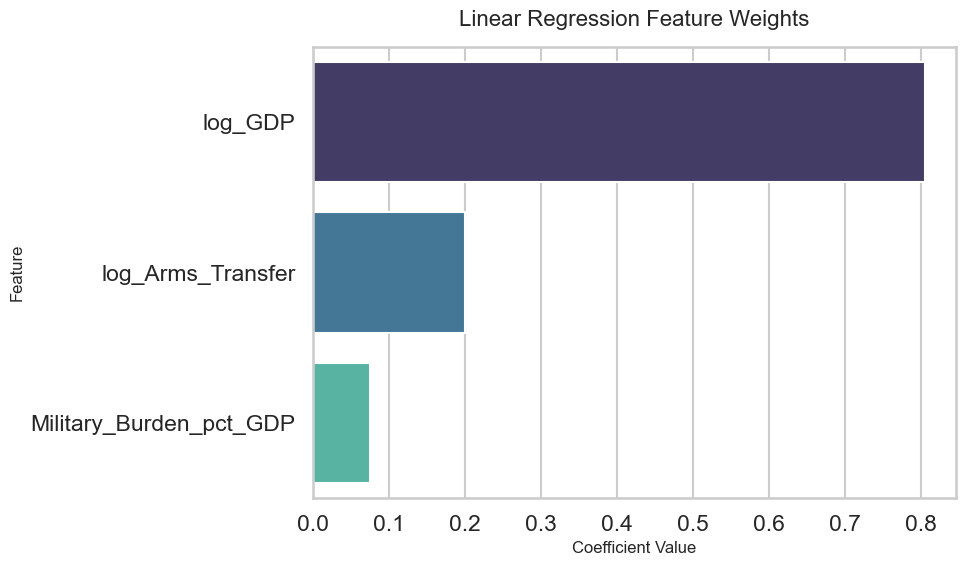

In [12]:
# -----------------------------
# 10. Interactive Linear Regression Model
# -----------------------------
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import ipywidgets as widgets
from IPython.display import display
import plotly.express as px

# Prepare data for regression to predict Military Spending
regression_model_df = latest_df[['Country', 'GDP', 'Arms_Transfer_Value', 'Military_Burden_pct_GDP', 'Arms_Dependency_Ratio', 'Military_Spending']].copy()
regression_model_df = regression_model_df.dropna(subset=['Military_Spending', 'GDP']).copy()

# Use log transformations due to extreme skewness
regression_model_df['log_Military_Spending'] = np.log10(regression_model_df['Military_Spending'] + 1)
regression_model_df['log_GDP'] = np.log10(regression_model_df['GDP'] + 1)
regression_model_df['log_Arms_Transfer'] = np.log10(regression_model_df['Arms_Transfer_Value'].fillna(0) + 1)

feature_cols = ['log_GDP', 'log_Arms_Transfer', 'Military_Burden_pct_GDP']
X = regression_model_df[feature_cols].copy()
y = regression_model_df['log_Military_Spending'].copy()

imputer = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=feature_cols, index=X.index)

X_train, X_test, y_train, y_test = train_test_split(X_imputed, y, test_size=0.30, random_state=42)

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred = lr_model.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f'Linear Regression Model Performance:')
print(f'R^2 Score: {r2:.3f}')
print(f'RMSE (Log Scale): {rmse:.3f}\n')

# Create an interactive scatter plot of True vs Predicted Values
results_df = pd.DataFrame({'True Log Spending': y_test, 'Predicted Log Spending': y_pred})
results_df['Country'] = regression_model_df.loc[y_test.index, 'Country']
results_df['Residual'] = results_df['True Log Spending'] - results_df['Predicted Log Spending']

fig = px.scatter(
    results_df,
    x='True Log Spending',
    y='Predicted Log Spending',
    hover_name='Country',
    hover_data={'Residual': ':.3f'},
    title='Interactive Prediction Analysis: True vs Predicted Military Spending (Log Scale)',
    color='Residual',
    color_continuous_scale='RdBu',
    color_continuous_midpoint=0,
    labels={'True Log Spending': 'Actual (Log US$)', 'Predicted Log Spending': 'Predicted (Log US$)'}
)

fig.add_shape(
    type="line", line=dict(dash='dash', color='black', width=2),
    x0=results_df['True Log Spending'].min(), y0=results_df['True Log Spending'].min(),
    x1=results_df['True Log Spending'].max(), y1=results_df['True Log Spending'].max()
)
fig.show()

# Feature Importance (Coefficients)
coefficients = pd.DataFrame({'Feature': feature_cols, 'Coefficient': lr_model.coef_}).sort_values('Coefficient', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=coefficients, x='Coefficient', y='Feature', hue='Feature', palette='mako', legend=False)
plt.title('Linear Regression Feature Weights', fontsize=16, pad=15)
plt.xlabel('Coefficient Value', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.tight_layout()
plt.show()


## 7. Major Findings And Final Conclusion

- Military spending is highly concentrated in a small number of countries, with the United States and China far ahead of most others.
- GDP explains a large share of military spending differences, but some countries spend much more than their economic size alone would predict.
- Military burden as a share of GDP highlights a different pattern from absolute spending and helps identify countries under stronger defense pressure.
- Arms transfer values do not perfectly track total military spending, which suggests different procurement strategies and domestic production capacity.
- The Linear Regression model shows that GDP is the strongest predictor of military spending, and the interactive visualizations reveal specific countries that deviate significantly from expected spending levels.

Overall, this project demonstrates a complete data science workflow by combining data collection, cleaning, preparation, visualization, regression, and interactive analytics in one integrated defense-economics study.


In [13]:
# -----------------------------
# 10. Final validation outputs
# -----------------------------

print('SIPRI long table:', sipri_long.shape)
print('GDP long table:', gdp_long.shape)
print('Arms summary table:', arms_summary.shape)
print('Arms yearly long table:', arms_long.shape)
print('Merged table:', merged.shape)

print('\nSample countries missing GDP matches after standardization:')
missing_gdp = sorted(set(sipri_long['Country']) - set(gdp_long['Country']))[:20]
print(missing_gdp)

print('\nSample countries missing arms-transfer matches after standardization:')
missing_arms = sorted(set(sipri_long['Country']) - set(arms_long['Country']))[:20]
print(missing_arms)

display(merged.sample(10, random_state=42))

SIPRI long table: (8846, 3)
GDP long table: (14561, 3)
Arms summary table: (140, 2)
Arms yearly long table: (2913, 3)
Merged table: (8846, 9)

Sample countries missing GDP matches after standardization:
['Cote dIvoire', 'Czechoslovakia', 'German Democratic Republic', 'North Korea', 'Somalia', 'Taiwan', 'USSR', 'Yemen, North', 'Yugoslavia']

Sample countries missing arms-transfer matches after standardization:
['Afghanistan', 'Belize', 'Benin', 'Bolivia', 'Bosnia and Herzegovina', 'Botswana', 'Burkina Faso', 'Burundi', 'Cabo Verde', 'Cameroon', 'Central African Republic', 'Democratic Republic of the Congo', 'Djibouti', 'El Salvador', 'Equatorial Guinea', 'Eswatini', 'European Union', 'Gambia', 'German Democratic Republic', 'Guinea']


,Country,Year,Military_Spending,GDP,Arms_Transfer_Value,Military_Spending_USD,Military_Burden_pct_GDP,Arms_Dependency_Ratio,Spending_Scaled
8107,Seychelles,2020,19.41,"1,382,551,751.57",NaN,"19,413,071.36",1.40,NaN,0.00
3580,Sierra Leone,1990,12.39,"649,644,097.57",NaN,"12,387,253.54",1.91,NaN,0.00
4273,Togo,1995,30.85,"1,849,110,468.20",NaN,"30,852,572.78",1.67,NaN,0.00
8821,Greece,2024,"8,021.96","256,238,371,778.12",20.00,"8,021,963,044.45",3.13,0.00,0.01
2697,Cote dIvoire,1983,76.25,NaN,NaN,"76,251,882.88",NaN,NaN,0.00
4691,Madagascar,1998,50.45,"4,401,967,632.74",NaN,"50,446,576.25",1.15,NaN,0.00
841,Sierra Leone,1965,2.51,"359,379,856.25",NaN,"2,505,999.00",0.70,NaN,0.00
2481,Sierra Leone,1981,15.79,"1,114,830,471.92",NaN,"15,788,111.47",1.42,NaN,0.00
1087,Cote dIvoire,1968,15.31,NaN,NaN,"15,305,071.40",NaN,NaN,0.00
2729,Guatemala,1983,184.25,"9,050,000,400.00",NaN,"184,250,000.00",2.04,NaN,0.00
